# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [56]:
import pandas as pd
import numpy as np
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, TimeDistributed, Reshape
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [57]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

No GPU found.


In [58]:
# First removing the path by split and then splitting the string to get the label
# input_path = [i for i in glob('Dataset\*\*\*.mp4')]
input_path = [i for i in glob('MP_Data\*\*.npy') if 'centered' not in i]
output_label = [i.split("\\")[-1] for i in glob('MP_data\*')] 

print(output_label)
input_path[:5]

['Blind', 'Deaf', 'Flat', 'Happy', 'Poor', 'Quiet', 'Rich', 'sad', 'Slow', 'Thick']


['MP_Data\\Blind\\1-1.npy',
 'MP_Data\\Blind\\1-2.npy',
 'MP_Data\\Blind\\1-3.npy',
 'MP_Data\\Blind\\1-4.npy',
 'MP_Data\\Blind\\1-5.npy']

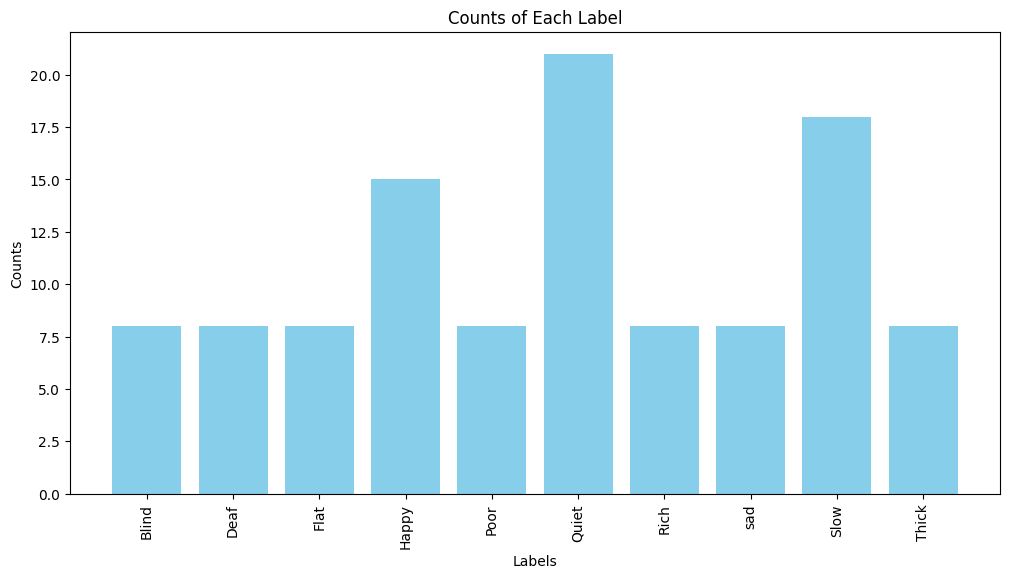

In [59]:
import matplotlib.pyplot as plt

# Count the occurrences of each label in y
label_counts = [len(os.listdir(i)) for i in glob('MP_data\*')]

# Create a bar graph
plt.figure(figsize=(12, 6))
plt.bar(output_label, label_counts, color='skyblue')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Counts of Each Label')
plt.xticks(rotation=90)
plt.show()

In [60]:
labels = pd.Series(output_label).unique()
labels = pd.Series(labels).to_list()

train_path = pd.Series(input_path)

train_path.sample(5),len(labels)

(1          MP_Data\Blind\1-2.npy
 39       MP_Data\Poor\Poor-1.npy
 48    MP_Data\Quiet\quiet-10.npy
 32     MP_Data\Happy\Happy-3.npy
 11       MP_Data\Deaf\Deaf-4.npy
 dtype: object,
 10)

In [61]:
label_map = dict()

for i in range(len(labels)):
    for j in input_path:
        sep = j.split("\\")
        cur_label  = sep[-2].split(" ")[-1]
    label_map[i] = labels[i]
            
label_map    

{0: 'Blind',
 1: 'Deaf',
 2: 'Flat',
 3: 'Happy',
 4: 'Poor',
 5: 'Quiet',
 6: 'Rich',
 7: 'sad',
 8: 'Slow',
 9: 'Thick'}

In [62]:
# Loading all the labeled videos in the dataset
X = []
y = []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label) 
    
    for video in label_videos[:8]:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        print(video,len(res))
                
        X.append(res)
        y.append(labels.index(label))      

len(X),len(y)

  0%|          | 0/10 [00:00<?, ?it/s]

1-1.npy 11
1-2.npy 9
1-3.npy 11
1-4.npy 10
1-5.npy 12
1-6.npy 9
1-7.npy 10
1-8.npy 12
Deaf-1.npy 10
Deaf-2.npy 12
Deaf-3.npy 12
Deaf-4.npy 8
Deaf-5.npy 15
Deaf-6.npy 15
Deaf-7.npy 13
Deaf-8.npy 12
Flat-1.npy 15
Flat-2.npy 23
Flat-3.npy 21
Flat-4.npy 21
Flat-5.npy 16
Flat-6.npy 21
Flat-7.npy 23
Flat-8.npy 18
Happy-1.npy 15
Happy-10.npy 15
Happy-11.npy 15
Happy-12.npy 15
Happy-13.npy 15
Happy-14.npy 15
Happy-15.npy 15
Happy-2.npy 15
Poor-1.npy 14
Poor-2.npy 18
Poor-3.npy 17
Poor-4.npy 14
Poor-5.npy 12
Poor-6.npy 15
Poor-7.npy 13
Poor-8.npy 18
quiet-1.npy 21
quiet-10.npy 14
quiet-11.npy 15
quiet-12.npy 13
quiet-13.npy 15
quiet-14.npy 5
quiet-15.npy 13
quiet-16.npy 21
Rich-1.npy 14
Rich-2.npy 11
Rich-3.npy 9
Rich-4.npy 6
Rich-5.npy 13
Rich-6.npy 12
Rich-7.npy 13
Rich-8.npy 12
sad-1.npy 15
sad-2.npy 15
sad-3.npy 16
sad-4.npy 15
sad-5.npy 14
sad-6.npy 15
sad-7.npy 15
sad-8.npy 12
Slow-1.npy 25
Slow-10.npy 21
Slow-11.npy 28
Slow-12.npy 25
Slow-13.npy 24
Slow-14.npy 24
Slow-15.npy 27
Slow-16.n

(80, 80)

In [63]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))
# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
print(f"Max frames: {max_frames}")

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape) # (number of videos, max frames, features)

Max frames: 28
(80, 28, 17)


In [64]:
X= np.array(X)
y= np.array(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (64, 28, 17)
X_val shape: (16, 28, 17)
y_train shape: (64, 10)
y_val shape: (16, 10)


# Model

## Architecture

In [65]:
import keras

input_shape = X_train[0].shape #(max_frames, features)
num_classes =  len(label_map.keys())

print(f"Input Shape: {input_shape}")
print(f"Number of Classes: {num_classes}")

Input Shape: (28, 17)
Number of Classes: 10


In [ ]:
INCLUDE8_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_6 (Bidirectio  (None, 79, 128)          165376    
 nal)                                                            
                                                                 
 bidirectional_7 (Bidirectio  (None, 79, 128)          98816     
 nal)                                                            
                                                                 
 bidirectional_8 (Bidirectio  (None, 79, 128)          98816     
 nal)                                                            
                                                                 
 bidirectional_9 (Bidirectio  (None, 79, 128)          98816     
 nal)                                                            
                                                                 
 flatten_9 (Flatten)         (None, 10112)            

In [49]:
INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 28, 128)        │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 28, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 28, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3584)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │       229,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 700,330 (2.67 MB)

 Trainable params: 700,330 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GRU,Masking


INCLUDE_V4 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        GRU(64, return_sequences=True),
        GRU(128, return_sequences=True),
        GRU(64, return_sequences=True),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE_V4

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 28, 64)         │        15,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 28, 128)        │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 28, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,842 (956.41 KB)

 Trainable params: 244,842 (956.41 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
INCLUDE8_V5 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        LSTM(64, return_sequences=True),
        LSTM(128, return_sequences=True),
        # LSTM(128, return_sequences=True),
        LSTM(64, return_sequences=True),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V5

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 28, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 28, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 28, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       114,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,866 (1.09 MB)

 Trainable params: 285,866 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=50
          ,callbacks=[early_stop])

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 478ms/step - accuracy: 0.1875 - loss: 2.2502 - val_accuracy: 0.1875 - val_loss: 2.1828
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4792 - loss: 2.0211 - val_accuracy: 0.1875 - val_loss: 2.0017
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5417 - loss: 1.7429 - val_accuracy: 0.2500 - val_loss: 1.8096
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5000 - loss: 1.5043 - val_accuracy: 0.3750 - val_loss: 1.5947
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6042 - loss: 1.2872 - val_accuracy: 0.6250 - val_loss: 1.3975
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6771 - loss: 1.0606 - val_accuracy: 0.4375 - val_loss: 1.2405
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6979 - loss: 0.9056 - val_accuracy: 0.6875 - val_loss: 1.0816
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7604 - loss: 0.8373 - val_accuracy: 0.6875 - val_loss: 0.9310

## Model Reuslts

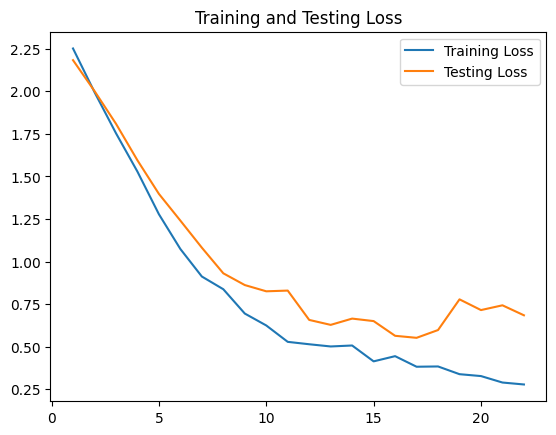

<Figure size 640x480 with 0 Axes>

In [68]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

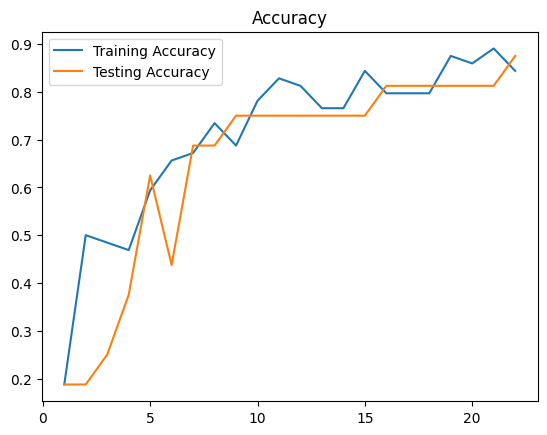

<Figure size 640x480 with 0 Axes>

In [69]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 


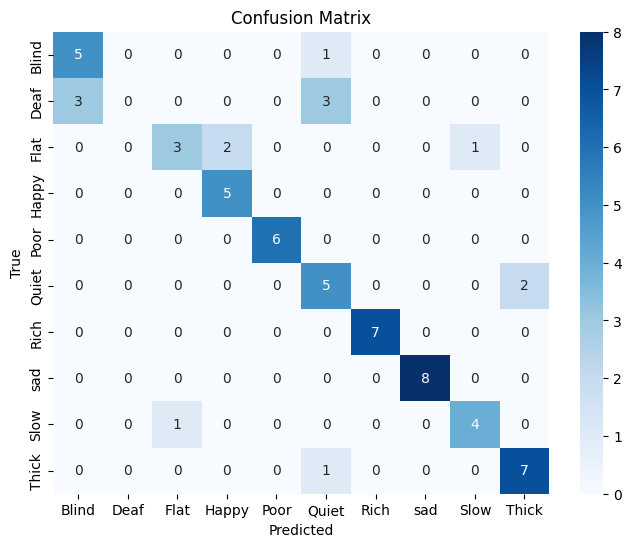

In [70]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Convert one-hot encoded y_val to class labels
true_classes = np.argmax(y_train, axis=-1)

probabilities = model.predict(X_train)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

plt.show()

In [71]:
# Accuracy
total = len(X_train)
pred = 0

for i in range(total):
   if (label_map[predicted_classes[i]]) == (label_map[np.argmax(y_train[i])]):
         pred += 1
 
acc = (pred/total)*100

f"Acc, Total, Pred: {acc}, {total}, {pred}"

'Acc, Total, Pred: 78.125, 64, 50'

### Saving Model

In [72]:
try:
    os.mkdir("Model")
except:
    pass

model.save("Model\INCLUDE_10_V4_angled.h5")